In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import cv2
import sklearn
import PIL
import torch
import torchvision
from matplotlib import cm

import warnings
warnings.filterwarnings('ignore')

### Зачем
- Посмотрим, как проводится операция свертки;
- Посмотрим, как работает pooling;
- Попробуем собрать сверточную нейронную сеть на PyTorch

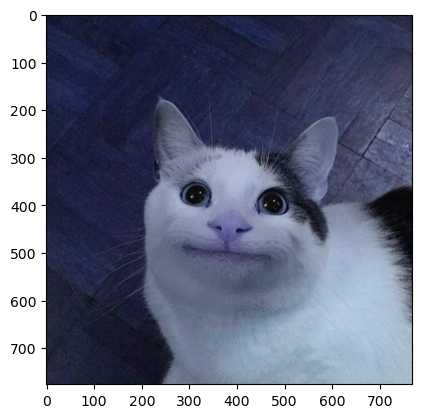

In [5]:
image = cv2.imread('./image.png')
plt.imshow(image)
plt.show()

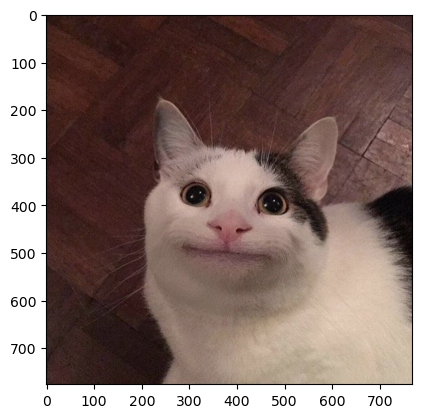

In [6]:
image_ex = image[...,::-1]
plt.imshow(image_ex)
plt.show()

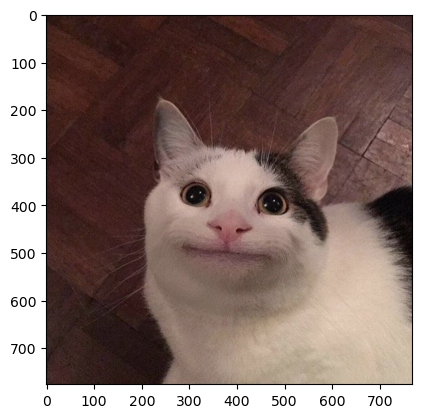

In [7]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.show()

Посмотрим на каналы изображения отдельно

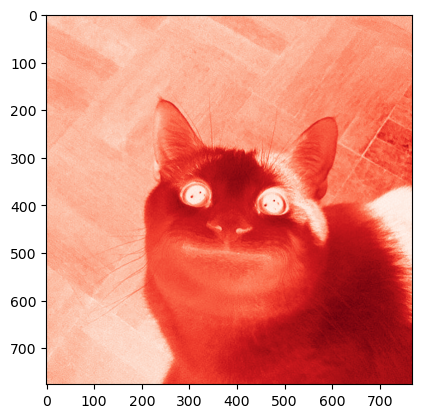

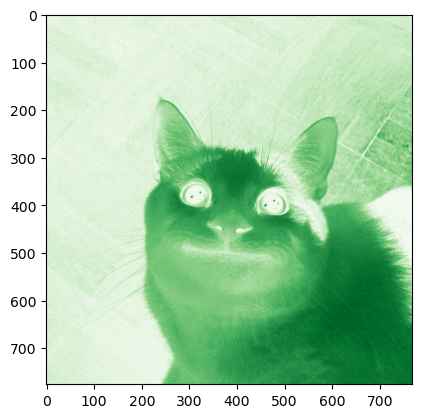

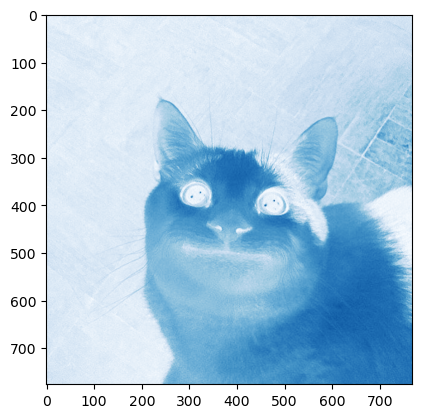

In [8]:
img_mat = np.array(image_rgb)
plt.imshow(img_mat[:, :, 0], cmap=cm.Reds)
plt.show()

img_mat = np.array(image_rgb)
plt.imshow(img_mat[:, :, 1], cmap=cm.Greens)
plt.show()

img_mat = np.array(image_rgb)
plt.imshow(img_mat[:, :, 2], cmap=cm.Blues)
plt.show()

# Операция свертки

- Количество входных каналов `in_channels`
- Количество выходных каналов `out_channels`
- Размер ядра `kernel_size`
- Шаг `stride`
- Паддинг `padding`
- Режим паддинга `padding_mode` (`'zeros'`, `'reflect'`, ...)


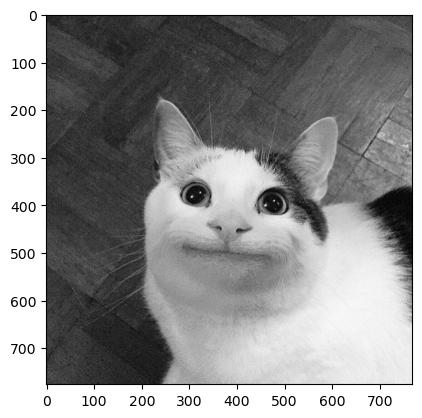

In [9]:
bw_image = cv2.imread('./image.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(bw_image, cmap=plt.cm.Greys_r)
plt.show()

In [7]:
# !pip3 install scipy

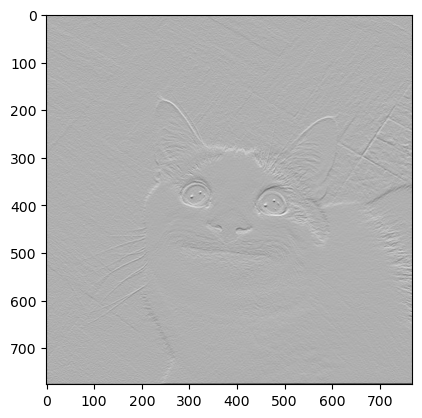

In [11]:
from scipy.signal import convolve2d

G_y = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
])

res_y = convolve2d(bw_image, G_y, "same")
plt.imshow(res_y, cmap=plt.cm.Greys_r)
plt.show()

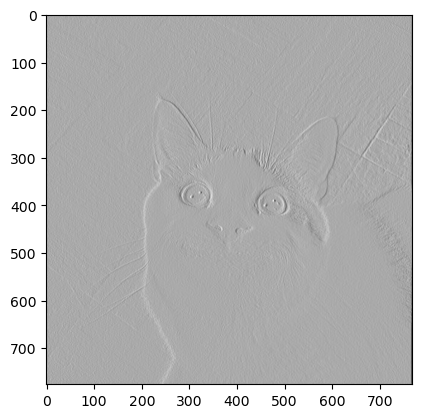

In [13]:
G_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

res_x = convolve2d(bw_image, G_y.T, "same")
plt.imshow(res_x, cmap=plt.cm.Greys_r)
plt.show()

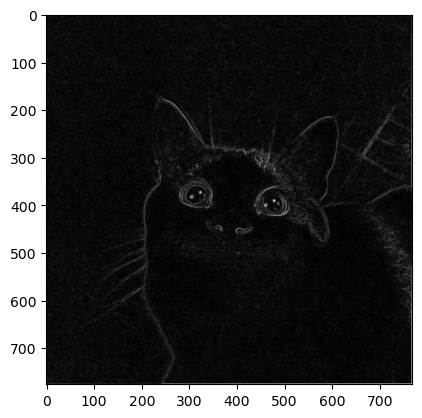

In [14]:
res_sobel = (res_x**2 + res_y**2)**0.5
plt.imshow(res_sobel, cmap=plt.cm.Greys_r)
plt.show()

# Пулинг

In [15]:
import numpy as np

conv_output = np.array([
    [10, 12,  8,  7],
    [ 4, 11,  5,  9],
    [18, 13,  7,  7],
    [ 3, 15,  2,  2]
])
conv_output

array([[10, 12,  8,  7],
       [ 4, 11,  5,  9],
       [18, 13,  7,  7],
       [ 3, 15,  2,  2]])

Сначала попробуем со `stride=2`

In [17]:
pool_size = 2
stride = 2

def get_pools(img=conv_output, pool_size=2, stride=2):

    pools = []
    for i in np.arange(conv_output.shape[0], step=stride):
        for j in np.arange(conv_output.shape[0], step=stride):
            mat = conv_output[i:i+pool_size, j:j+pool_size]
            pools.append(mat)
    pools = np.array(pools)
    return pools

pools = get_pools()
pools

array([[[10, 12],
        [ 4, 11]],

       [[ 8,  7],
        [ 5,  9]],

       [[18, 13],
        [ 3, 15]],

       [[ 7,  7],
        [ 2,  2]]])

In [18]:
def max_pooling(pools: np.array) -> np.array:

    num_pools = pools.shape[0]

    # Размер матрицы после пулинга
    tgt_shape = (int(np.sqrt(num_pools)), int(np.sqrt(num_pools)))

    # Здесь будем хранить максимумы с каждого из пулов
    pooled = []
    for pool in pools:
        pooled.append(np.max(pool))

    return np.array(pooled).reshape(tgt_shape)

In [19]:
max_pooling(pools=pools)

array([[12,  9],
       [18,  7]])

# Сверточная нейронная сеть

In [20]:
import torch
import torch.nn.functional as F
import torchvision
import os
from torch import nn
from tqdm import tqdm

In [21]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,))
    ]
)

In [22]:
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [23]:
seed_everything(42)

mnist_train = torchvision.datasets.MNIST(
    './mnist/',
    train=True,
    download=True,
    transform=transform
)

mnist_val = torchvision.datasets.MNIST(
    './mnist/',
    train=False,
    download=True,
    transform=transform
)

train_dataloader = torch.utils.data.DataLoader(mnist_train, batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(mnist_val, batch_size=64, shuffle=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:11<00:00, 850kB/s] 


Extracting ./mnist/MNIST\raw\train-images-idx3-ubyte.gz to ./mnist/MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 253kB/s]


Extracting ./mnist/MNIST\raw\train-labels-idx1-ubyte.gz to ./mnist/MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:02<00:00, 695kB/s] 


Extracting ./mnist/MNIST\raw\t10k-images-idx3-ubyte.gz to ./mnist/MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

Extracting ./mnist/MNIST\raw\t10k-labels-idx1-ubyte.gz to ./mnist/MNIST\raw



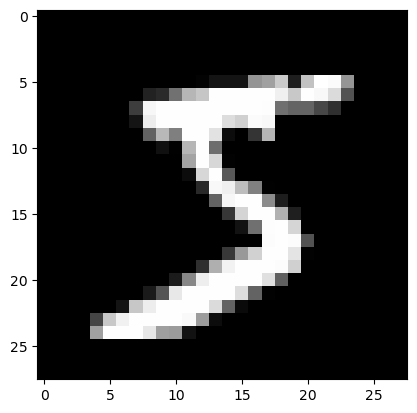

In [33]:
plt.imshow(mnist_train[0][0].squeeze(0).numpy().reshape([28, 28]), cmap=plt.cm.Greys_r)
plt.show()

In [34]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [35]:
def train(model, optimizer, n_epochs=5):
    for epoch in range(n_epochs):

        # обучение
        for x_train, y_train in tqdm(train_dataloader):
            y_pred = model(x_train)
            loss = F.cross_entropy(y_pred, y_train)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        # валидация
        if epoch % 2 == 0:
            val_loss = []
            val_accuracy = []
            with torch.no_grad():
                for x_val, y_val in tqdm(val_dataloader):
                    y_pred = model(x_val)
                    loss = F.cross_entropy(y_pred, y_val)
                    val_loss.append(loss.numpy())
                    val_accuracy.extend((torch.argmax(y_pred, dim=-1) == y_val).numpy().tolist())

            print(f'Epoch: {epoch}, loss: {np.mean(val_loss)}, accuracy: {np.mean(val_accuracy)}')

In [36]:
train(model, optimizer)

100%|██████████| 157/157 [00:01<00:00, 82.50it/s]


Epoch: 0, loss: 0.3204896152019501, accuracy: 0.9101


100%|██████████| 157/157 [00:01<00:00, 86.57it/s]


Epoch: 2, loss: 0.2286842316389084, accuracy: 0.934


100%|██████████| 157/157 [00:01<00:00, 83.98it/s]

Epoch: 4, loss: 0.18556907773017883, accuracy: 0.9459


In [27]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5),  # grayscale
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=4),   # сократим изображение в 4 раза по каждой из сторон
    nn.Flatten(),
    nn.Linear(6*6*10, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [28]:
train(model, optimizer)

100%|██████████| 157/157 [00:02<00:00, 75.12it/s]


Epoch: 0, loss: 0.22864311933517456, accuracy: 0.9332


100%|██████████| 157/157 [00:02<00:00, 75.65it/s]


Epoch: 2, loss: 0.10849902778863907, accuracy: 0.9685


100%|██████████| 157/157 [00:02<00:00, 67.09it/s]

Epoch: 4, loss: 0.08062831312417984, accuracy: 0.9753


In [27]:
0.9747

0.9747

# Домашнее задание

Обучите сверточную нейронную сеть на датасете MNIST, взяв любой другой оптимизатор (кроме SGD) и любую другую функцию ошибки (кроме cross-entropy loss). Попробуйте поварьировать параметры: кол-во ядер, `kernel_size` и побить текущий бейзлайн в `0.9747`. Выведите количество обучаемых параметров.    
Какого качества удалось достичь? Попробуйте залоггировать Ваши результаты - построить графики того, как менялись метрики качества (accuracy, loss) с течением эпох, включить логгирование, сравнить результаты между собой при разных параметрах.

Любые дополнительные улучшения (как по методам, так и по коду пайплайна) приветствуются!

*Цель:* выработать навык обучения нейронных сетей (в частности сверточных) на основе средств PyTorch, начиная от загрузки датасетами и заканчивая выводами результатов, их логгированием, сравнением и анализом.

## Загрузка датасета

Преобразования картинок + аугментация случайными поворотами на train

In [56]:
train_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.RandomRotation((-15, 15)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,))
    ]
)
test_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,))
    ]
)

Непосредственно загрузка датасетов

In [57]:
seed_everything(777)

mnist_train = torchvision.datasets.MNIST(
    './mnist/',
    train=True,
    download=True,
    transform=train_transform
)

mnist_val = torchvision.datasets.MNIST(
    './mnist/',
    train=False,
    download=True,
    transform=test_transform
)

train_dataloader = torch.utils.data.DataLoader(mnist_train, batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(mnist_val, batch_size=64, shuffle=True)

## Цикл обучения

In [84]:
import typing as tt

def train(
        network,
        optimizer,
        objective,
        n_epochs=5,
        validate_every_iter=2
) -> tt.Tuple[tt.List[float], tt.List[float]]:
    loss_history = []
    accy_history = []
    for epoch in range(n_epochs):
        # обучение
        for x_train, y_train in tqdm(train_dataloader):
            optimizer.zero_grad()
            y_pred = network(x_train)
            loss = objective(y_pred, y_train)
            loss.backward()
            optimizer.step()
        # валидация
        if epoch % validate_every_iter == 0:
            curr_loss = []
            curr_accy = []
            with torch.no_grad():
                for x_val, y_val in tqdm(val_dataloader):
                    y_pred = network(x_val)
                    curr_loss.append(float(objective(y_pred, y_val).item()))
                    curr_accy.extend((torch.argmax(y_pred, dim=-1) == y_val).numpy().tolist())
            loss = float(np.mean(curr_loss))
            accy = float(np.mean(curr_accy))
            print(f"Epoch: {epoch}, loss: {loss}, accuracy: {accy}")
            loss_history.append(loss)
            accy_history.append(accy)
    return loss_history, accy_history

## Модель

In [85]:
model = nn.Sequential(
    # 1 x 28 x 28
    nn.Conv2d(1, 4, kernel_size=3),
    nn.ReLU(),
    # 4 x 26 x 26
    nn.Conv2d(4, 8, kernel_size=3),
    nn.ReLU(),
    # 8 x 24 x 24
    nn.Conv2d(8, 16, kernel_size=3),
    nn.ReLU(),
    # 16 x 22 x 22
    nn.MaxPool2d(kernel_size=2),
    # 16 x 11 x 11
    nn.Conv2d(16, 32, kernel_size=5),
    nn.ReLU(),
    # 32 x 7 x 7
    nn.MaxPool2d(kernel_size=2),
    # 32 x 3 x 3
    nn.Flatten(),
    nn.Linear(288, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

Структура и количество параметров

In [87]:
model

Sequential(
  (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1))
  (3): ReLU()
  (4): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (8): ReLU()
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Flatten(start_dim=1, end_dim=-1)
  (11): Linear(in_features=288, out_features=512, bias=True)
  (12): ReLU()
  (13): Linear(in_features=512, out_features=256, bias=True)
  (14): ReLU()
  (15): Linear(in_features=256, out_features=10, bias=True)
)

In [89]:
sum(p.numel() for p in model.parameters())

296202

## Оптимизатор и цель обучения

In [90]:
optimizer = torch.optim.Adam(model.parameters())

objective = nn.MultiMarginLoss()

## Обучение

In [91]:
history = train(model, optimizer, objective, validate_every_iter=1)

100%|██████████| 157/157 [00:02<00:00, 56.97it/s]


Epoch: 0, loss: 0.00691940691235889, accuracy: 0.9802


100%|██████████| 157/157 [00:02<00:00, 60.42it/s]


Epoch: 1, loss: 0.004302321651139094, accuracy: 0.9876


100%|██████████| 157/157 [00:02<00:00, 58.79it/s]


Epoch: 2, loss: 0.0034821556921817817, accuracy: 0.9907


100%|██████████| 157/157 [00:02<00:00, 60.58it/s]


Epoch: 3, loss: 0.004008975746270895, accuracy: 0.9891


100%|██████████| 157/157 [00:02<00:00, 64.81it/s]

Epoch: 4, loss: 0.0038822365626992616, accuracy: 0.9877


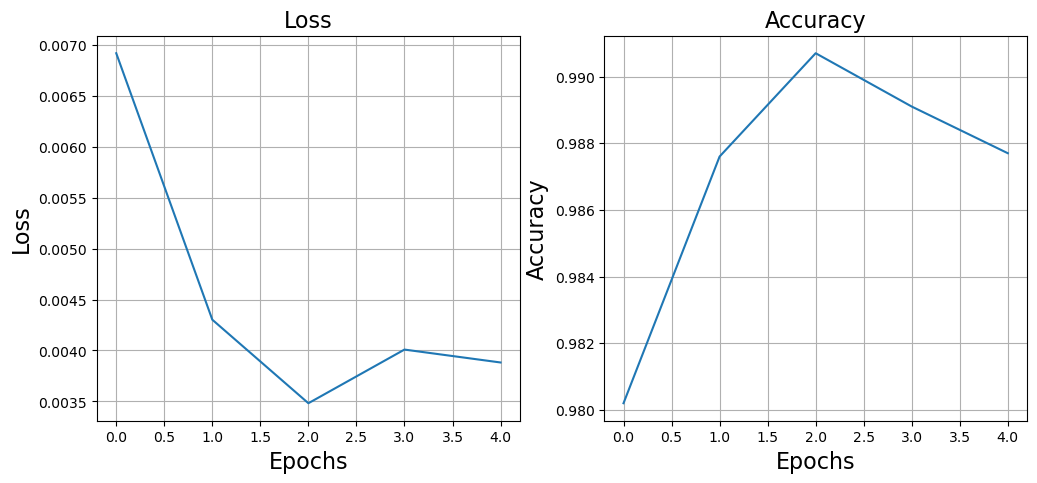

In [92]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Loss", fontsize=16)
plt.plot(history[0])
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.grid()

plt.subplot(1, 2, 2)
plt.title("Accuracy", fontsize=16)
plt.plot(history[1])
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.grid()

plt.show()

## Попробуем другую архитектуру

In [93]:
model = nn.Sequential(
    # 1 x 28 x 28
    nn.Conv2d(1, 64, kernel_size=7),
    nn.ReLU(),
    # 64 x 22 x 22
    nn.MaxPool2d(kernel_size=2),
    # 64 x 11 x 11
    nn.Conv2d(64, 128, kernel_size=5),
    nn.ReLU(),
    # 128 x 7 x 7
    nn.MaxPool2d(kernel_size=2),
    # 128 x 3 x 3
    nn.Conv2d(128, 256, kernel_size=3),
    nn.ReLU(),
    # 256 x 1 x 1
    nn.Flatten(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

model

Sequential(
  (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
  (7): ReLU()
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=256, out_features=128, bias=True)
  (10): ReLU()
  (11): Linear(in_features=128, out_features=10, bias=True)
)

In [94]:
sum(p.numel() for p in model.parameters())

537482

In [95]:
optimizer = torch.optim.Adam(model.parameters())

objective = nn.MultiMarginLoss()
history2 = train(model, optimizer, objective, validate_every_iter=1)

100%|██████████| 157/157 [00:03<00:00, 39.51it/s]


Epoch: 0, loss: 0.0047068758638279815, accuracy: 0.9861


100%|██████████| 157/157 [00:03<00:00, 39.45it/s]


Epoch: 1, loss: 0.004225150314526733, accuracy: 0.9879


100%|██████████| 157/157 [00:03<00:00, 40.38it/s]


Epoch: 2, loss: 0.0036995860297538226, accuracy: 0.9892


100%|██████████| 157/157 [00:03<00:00, 40.35it/s]


Epoch: 3, loss: 0.003895811619733916, accuracy: 0.9894


100%|██████████| 157/157 [00:04<00:00, 39.09it/s]

Epoch: 4, loss: 0.003856797320321484, accuracy: 0.9901


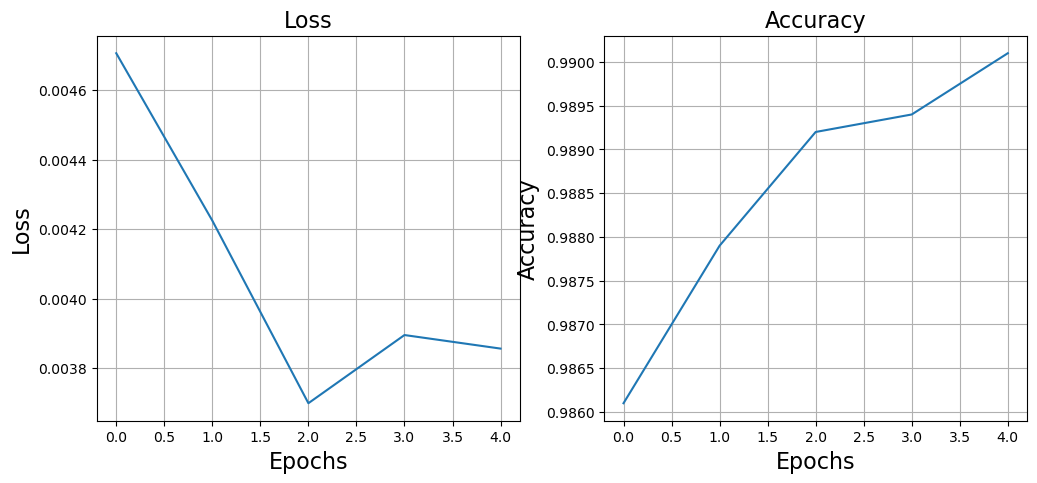

In [96]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Loss", fontsize=16)
plt.plot(history2[0])
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.grid()

plt.subplot(1, 2, 2)
plt.title("Accuracy", fontsize=16)
plt.plot(history2[1])
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.grid()

plt.show()

## Сравнение

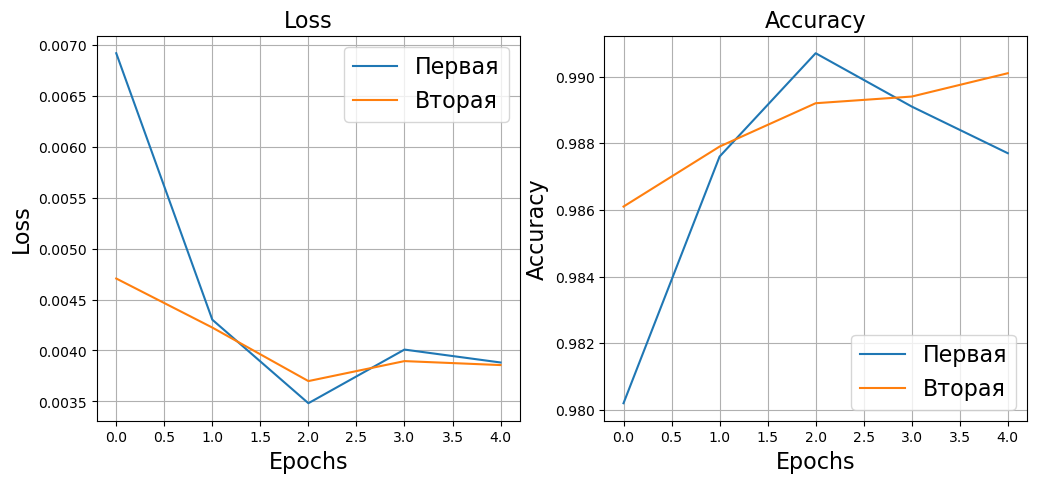

In [97]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Loss", fontsize=16)
plt.plot(history[0], label="Первая")
plt.plot(history2[0], label="Вторая")
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.legend(loc=0, fontsize=16)
plt.grid()

plt.subplot(1, 2, 2)
plt.title("Accuracy", fontsize=16)
plt.plot(history[1], label="Первая")
plt.plot(history2[1], label="Вторая")
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.legend(loc=0, fontsize=16)
plt.grid()

plt.show()

Первая модель в моменте была гораздо точнее второй, однако вторая имеет более стабильную кривую обучения, но и параметров почти в два раза больше))